# One-Way ANOVA
## Music Streaming Pipeline — Notebook 4

In this notebook I extend the hypothesis testing from Notebook 3 by moving from two-group comparisons to multi-group comparisons using one-way ANOVA. The key advantage of ANOVA over running multiple t-tests is that it tests all groups simultaneously in a single test, which avoids inflating the false positive rate that would result from running several pairwise comparisons independently. Where a result is significant, I follow up with a Tukey HSD post-hoc test to identify exactly which pairs of groups are driving the difference.

I run two separate ANOVA tests in this notebook. The first investigates whether song popularity differs significantly across the three album formats in the dataset — singles, albums, and compilations. The second asks a more interesting question: has the average popularity of songs changed across decades, and if so, which eras are genuinely different from each other?

For both tests I check the equal variance assumption using Levene's test and visualise the group distributions with boxplots before running the ANOVA. Effect size is reported as eta-squared (η²) alongside the F-statistic and p-value to distinguish between statistical significance and practical importance.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## LOAD DATA

In [2]:
data = pd.read_csv('../exports/merged_table.csv')

In [3]:
data.duplicated().sum()

np.int64(0)

## TEST 1: Does Song Popularity Differ by Album Format?

### Business Question
A streaming platform's editorial team wants to understand whether release format influences song popularity. Do singles, albums, and compilations perform differently, or is format irrelevant to how well a song performs?

### Hypotheses
* H0: Average song popularity is the same across singles, albums, and compilations.
* H1: At least one album format has a significantly different average popularity.
* Alpha: 0.05

In [4]:
df=data[['album_type', 'popularity']]

In [5]:
data.sample(10)

,Unnamed: 0,song_id,song_name,artist_id_x,album_id,song_listeners,mbid,duration_ms,duration_seconds,duration_minutes,...,created_at_y,artist_popularity,artist_followers,has_genres,album_title,artist_id_y,album_type,album_total_tracks,created_at,updated_at
100519,100519,57b0yB4iXafwe313OLikaF,the appearance of a star system,7jw2YyapcCq5bf8GTnhjLH,2yDUAuD1IJe5rOKim4DYRn,1051,e19449f2-dcdb-43b3-b14e-0e2a358584de,148914,148,2.47,...,2025-12-30 12:51:36.375671,23.0,320.0,t,no man's sky: journeys (original soundtrack),7jw2YyapcCq5bf8GTnhjLH,album,32,2025-12-30 12:51:36.376601,2025-12-30 12:51:36.376601
43005,43005,08pm1MMo9YlQzK3qTMxv7D,drained (sped up),5GU9U3XzlILSLN8HiYGAvc,5v2pSkaOwURomdpwfNJCNw,0,NaN,52335,52,0.87,...,2025-12-30 12:59:39.644293,NaN,NaN,f,parasocial (sped up),5GU9U3XzlILSLN8HiYGAvc,album,11,2025-12-30 12:59:39.658679,2025-12-30 12:59:39.66186
33935,33935,3fjr07n0jCIeWmD8qvB03e,breathe ~_~,6KAgrAiCdJPDucMqR1kvMn,6gUZt2h1YtyPms3Miyv2Ji,5387,1475c892-0079-4347-8d9d-549fbbbe7e86,203922,203,3.38,...,2025-12-30 13:24:56.875003,42.0,72174.0,t,breathe ~_~,6KAgrAiCdJPDucMqR1kvMn,single,1,2025-12-30 13:24:56.876558,2025-12-30 13:24:57.027836
99789,99789,63cOX7fjSdMN5AtZEirMFx,teddy is a bear,5Q7zEQv9vodtCdUZl98Ox0,2ewZYQEaiCT1e50pEqUYQM,1034,NaN,83528,83,1.38,...,2025-12-30 13:14:43.96932,56.0,199.0,t,teddy is a bear,5Q7zEQv9vodtCdUZl98Ox0,single,1,2025-12-30 13:14:44.04703,2025-12-30 13:14:45.508014
52132,52132,05hSCC5hwv2rR4EyuslURV,impressions - take 1,2hGh5VOeeqimQFxqXvfCUf,0NSRgubfAJoYv2kvVAcRKy,9337,b625448e-bf4a-41c3-a421-72ad46cdb831,246653,246,4.10,...,2025-12-30 12:25:28.607344,68.0,1860995.0,t,both directions at once: the lost album (delux...,2hGh5VOeeqimQFxqXvfCUf,album,14,2026-01-06 20:16:42.946471,2026-01-07 11:33:56.046037
55706,55706,0KvoG3YbeHn9LrgGZkjprB,leave the night chart bitches alone,1E0pbTfSqG4xZPMAlFQdbm,5r3vYZeIWrek5n5F7WwjCz,805,NaN,65257,65,1.08,...,2026-01-01 18:27:47.462487,NaN,NaN,f,leave the night chart bitches alone,1E0pbTfSqG4xZPMAlFQdbm,single,1,2026-01-01 18:27:47.463243,2026-01-01 18:27:47.463243
83930,83930,7tRIpQDyq22qkjdk4mzBrq,reason to believe,3eqjTLE0HfPfh78zjh6TqT,6yskFQZNlLYhkchAxELHi6,117357,70248960-cb53-4ea4-943a-edb18f7d336f,248625,248,4.13,...,2025-12-30 12:21:38.543423,80.0,7497983.0,f,nebraska,3eqjTLE0HfPfh78zjh6TqT,album,10,2025-12-30 13:02:06.04786,2026-01-07 19:36:05.711883
58627,58627,19zsSUEuJNzNA6eqInqyF9,make up (feat. crush),4BBN286rBKyCWsSPq2cxYO,0AsQlY5YENtlvd8SLnrSxX,52021,9d4916df-1f64-4469-824c-926817c32bc2,207493,207,3.45,...,2025-12-30 13:24:56.903988,55.0,489655.0,t,sun and moon,4BBN286rBKyCWsSPq2cxYO,album,8,2026-01-06 20:04:12.798439,2026-01-07 09:51:25.901523
59165,59165,6j1Hbe1pWgrewUProumbvI,manage,2mSG3T7khBUhqPmWGlX51f,2OWeJ2uoMt69RE7E86o1m1,0,NaN,212515,212,3.53,...,2026-01-06 19:06:51.101877,NaN,NaN,f,aesthetic,2mSG3T7khBUhqPmWGlX51f,album,17,2026-01-07 09:51:45.121136,2026-01-07 12:52:37.165987
30351,30351,2Tl0t18jgqJo0S7Fs2iy50,body language - intro,1U1el3k54VvEUzo3ybLPlM,4EPQtdq6vvwxuYeQTrwDVY,250941,d0c7656d-8169-4f77-9dbe-b8f24e40105d,136342,136,2.27,...,2025-12-30 12:21:39.356057,86.0,9864171.0,f,isolation,1U1el3k54VvEUzo3ybLPlM,album,15,2025-12-30 12:35:07.621332,2026-01-07 14:27:32.353747


In [6]:
df= data[['album_type', 'popularity', 'release_date']]

In [7]:
df['album_type']= df['album_type'].map({'single':0, 'album':1, 'compilation': 2})

/var/folders/9v/g0l2v7dn7b72486f6lzl24f40000gn/T/ipykernel_30789/3812015552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['album_type']= df['album_type'].map({'single':0, 'album':1, 'compilation': 2})


In [8]:
df.describe()

,album_type,popularity
count,109291.000000,109291.000000
mean,0.690871,28.882708
std,0.547506,19.358753
min,0.000000,1.000000
25%,0.000000,13.000000
50%,1.000000,26.000000
75%,1.000000,43.000000
max,2.000000,99.000000


In [9]:
singles = df[df['album_type']==0]['popularity']
albums = df[df['album_type']==1]['popularity']
compilations = df[df['album_type']==2]['popularity']

In [10]:
singles.describe()

count    38495.000000
mean        28.983504
std         18.770034
min          1.000000
25%         13.000000
50%         27.000000
75%         43.000000
max         96.000000
Name: popularity, dtype: float64

In [11]:
albums.describe()

count    66086.000000
mean        28.945223
std         19.736573
min          1.000000
25%         13.000000
50%         26.000000
75%         43.000000
max         99.000000
Name: popularity, dtype: float64

In [12]:
compilations.describe()

count    4710.000000
mean       27.181741
std        18.657208
min         1.000000
25%        11.000000
50%        24.000000
75%        41.000000
max        92.000000
Name: popularity, dtype: float64

As seen in the previous notebook there was a neglibible difference in average mean of song popularity in singles vs albums. However, since we are running an ANOVA test we can include more than 2 groups to test. The descriptive stats of compilations tell a slightly different story. With a lower average mean (27.18) compared to albums (28.94) and singles (28.98), compilations tend to perform slightly worse than their counterparts. This could be due to less marketing behind compilations, or the songs have already been released and therefore don't get the rush of streams a new single/album might. Compilations appear to share the same trends as singles and album songs however they recieve on average 2 fewer popularity points.

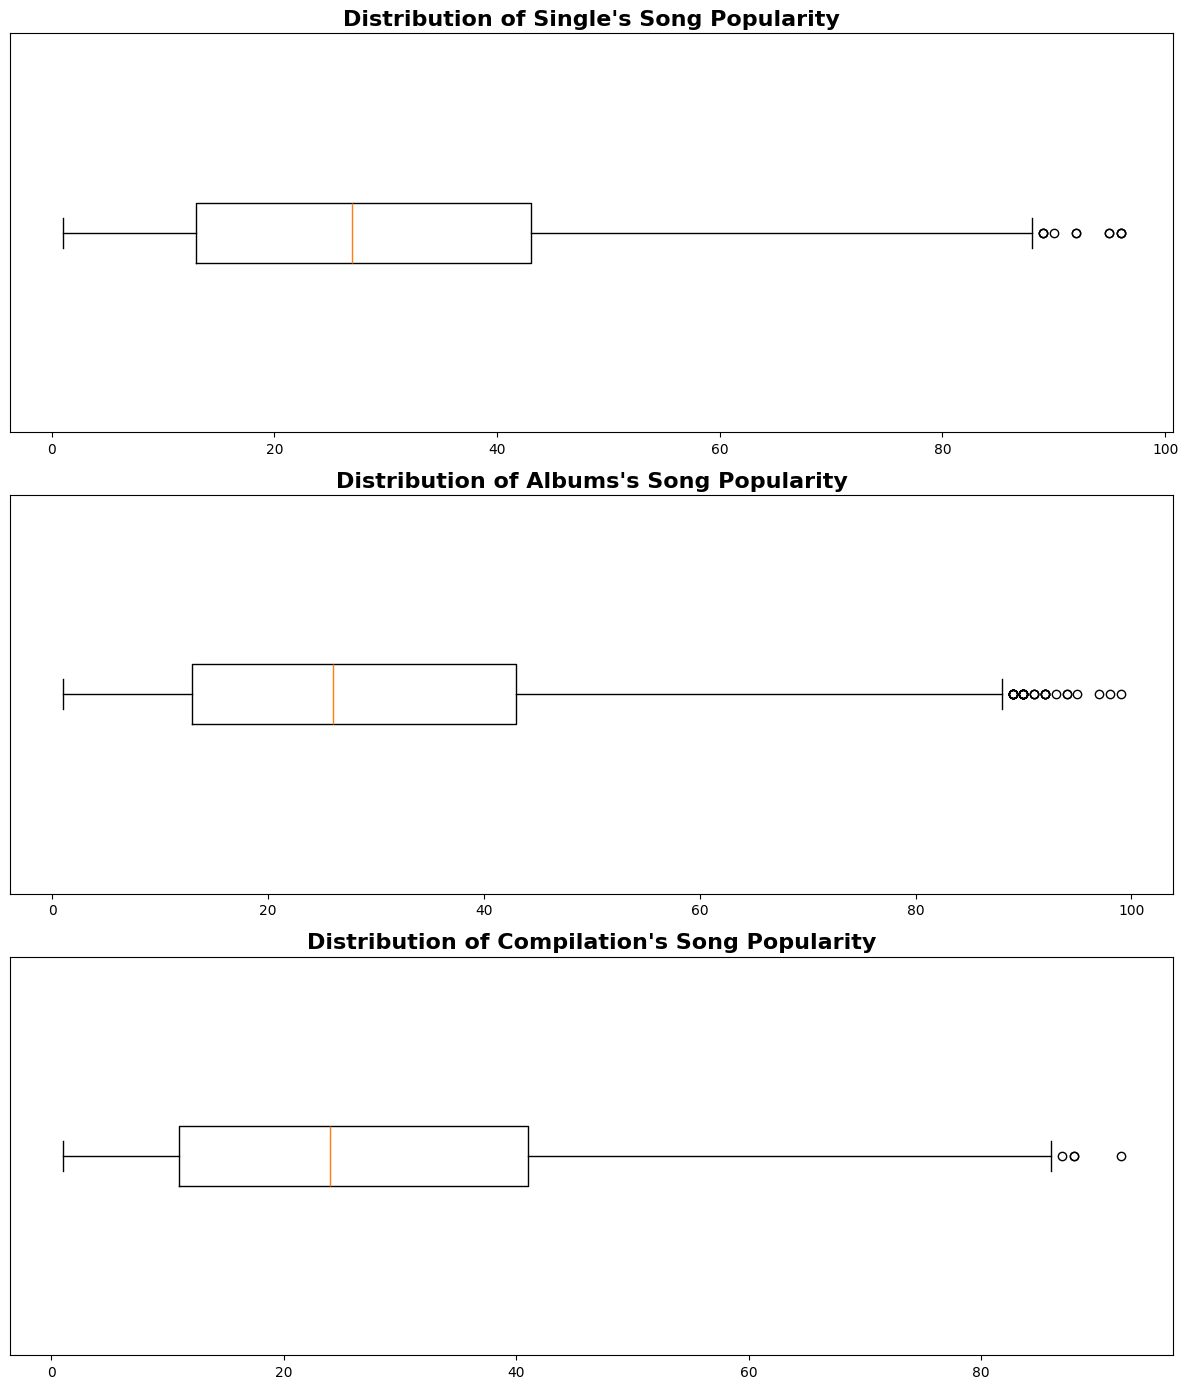

In [13]:
fig, axes = plt.subplots(3,1, figsize=(12,14))

axes[0].boxplot(singles, vert=False)
axes[0].set_title("Distribution of Single's Song Popularity", fontsize=16, fontweight='bold')
axes[0].set_yticks([])


axes[1].boxplot(albums, vert=False)
axes[1].set_title("Distribution of Albums's Song Popularity", fontsize=16, fontweight='bold')
axes[1].set_yticks([])

axes[2].boxplot(compilations, vert=False)
axes[2].set_title("Distribution of Compilation's Song Popularity", fontsize=16, fontweight='bold')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()


In [14]:
stat, p = levene(singles, albums, compilations)
print(f"Levene's test p = {p:.4f}")

Levene's test p = 0.0000


Observing the three plots, it is clear that visually the three groups show very simliar variances. Their IQR's, medians, whisket lengths, and outlier patterns are all extremely similar across the three groups. However, levene's returning a p-value of 0.00 is the same large-sample problem we observed in the previous notebook. With tens of thousands of rows per group, it can detect variance differences so tiny that they're invisible to the eye and meaningless in practice. THe test is being hypersensitive, not telling me something that is meaningful. I will continue with the ANOVA test since the visual evidence is strong enough to assert that the variances are similar.

In [15]:
f_stat, p_val = f_oneway(singles, albums, compilations)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.6f}")

if p_val < .05:
    print("Result: Reject the Null Hypothesis... at least one group's mean is significantly different ")
else:
    print("Result: Accept the Null Hypothesis... no significant difference between the groups' means")

F-statistic: 19.0541
p-value:     0.000000
Result: Reject the Null Hypothesis... at least one group's mean is significantly different 


The ANOVA test returned a p-value of 0.00 and a F-stat of 19.05. This translates to us rejecting the null hypothesis and asserting that one of the group's means was significantly different than the others. We can be confident about this because of our high F-stat. A higher F-stat means that we can be more confident that at least one group mean is genuinely different. Having an F-stat of 19.05 translates to the variance between the three groups' means is 19x larger than the variance within the groups. This communicates that the difference is not just noise, but signals that this difference is meaningful.

In [16]:
tukey = pairwise_tukeyhsd(endog=df['popularity'], groups = df['album_type'], alpha=.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -0.0383 0.9489 -0.3291  0.2526  False
     0      2  -1.8018    0.0  -2.502 -1.1015   True
     1      2  -1.7635    0.0 -2.4476 -1.0793   True
----------------------------------------------------


The tukey table informs me which pairs of the groups we are investigating drive the result.

* Single vs Album (0 vs 1): The mean difference between these two group's mean is -.0383 popularity points with a p-value of .95. This means there is no significant difference between these two group's means, causing us to accept the null hypothesis for these two specific groups.
* Single vs Compilation (0 vs 2): Compilations on average recieve a popularity score 1.8 less than singles. This is meaningful as our p-value is 0.0 allowing us to reject the null hypothesis. This states that the two groups means are significantly different from one another.
* Album vs Compilatin (1 vs 2): Compilations on average recieve a popularity score 1.76 less than album tracks. This is meaningful as our p-value is 0.0 allowing us to reject the null hypothesis. This states that the two groups means are significantly different from one another.

In conclusion, the compilations are the outlier, consistenly underperforming both singles and albums by a similar margin. Singles and albums are stastically indistinguishable from each other. The f stat of 19 appears to be completely driven by the compilation tracks, pulling the means apart.

In [17]:
grand_mean = df['popularity'].mean()
ss_between = sum( len(g)* (g.mean() - grand_mean)**2 for g in [singles, albums, compilations])
ss_total = sum((df['popularity']- grand_mean)**2)
eta_sq = ss_between/ss_total

print(f"\nEta-squared: {eta_sq:.4f}")
if eta_sq < 0.01:
    print("Effect size: Negligible")
elif eta_sq < 0.06:
    print("Effect size: Small")
elif eta_sq < 0.14:
    print("Effect size: Medium")
else:
    print("Effect size: Large")


Eta-squared: 0.0003
Effect size: Negligible


The Eta-squared value means that album type drives .003% of the variance observed in the song popularity. The other 99.97% of the variance in song popularity is explain by other factors.

## TEST 2: Has Song Popularity Changed Across Decades?

### Business Question
A label wants to understand whether older catalogue songs perform differently from newer releases on Spotify. Are songs from the 1960s and 1970s genuinely more popular today than songs from the 2010s and 2020s, and if so, which specific decade pairs are driving that difference?

### Hypotheses
H0: Average song popularity is the same across all decades.
H1: At least one decade has a significantly different average popularity.
Alpha: 0.05

In [18]:
df['decade'] = (pd.to_datetime(df['release_date'], format='mixed').dt.year // 10 * 10).astype(str) + 's'
df['decade'].value_counts().sort_index()

/var/folders/9v/g0l2v7dn7b72486f6lzl24f40000gn/T/ipykernel_30789/931364795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['decade'] = (pd.to_datetime(df['release_date'], format='mixed').dt.year // 10 * 10).astype(str) + 's'


decade
1900s        5
1920s        3
1930s        2
1940s       11
1950s      195
1960s      780
1970s     1360
1980s     2193
1990s     4668
2000s     9419
2010s    25352
2020s    65303
Name: count, dtype: int64

In [19]:
valid_decades = df['decade'].value_counts()
valid_decades = valid_decades[valid_decades >=500].index
df= df[df['decade'].isin(valid_decades)]
df['decade'].value_counts()


decade
2020s    65303
2010s    25352
2000s     9419
1990s     4668
1980s     2193
1970s     1360
1960s      780
Name: count, dtype: int64

In [27]:
sixties = df[df['decade']=='1960s']['popularity']
seventies = df[df['decade']=='1970s']['popularity']
eighties = df[df['decade']=='1980s']['popularity']
ninties = df[df['decade']=='1990s']['popularity']
y2k = df[df['decade']=='2000s']['popularity']
tens = df[df['decade']=='2010s']['popularity']
twenties = df[df['decade']=='2020s']['popularity']

In [28]:
for table, decade in [(sixties, '1960s'), (seventies, '1970s'), (eighties, '1980s'), (ninties, '1990s'), (y2k, '2000s'), (tens, '2010s'), (twenties, '2020s')]:
    print(f'{decade.upper()}')
    print(table.describe())
    print()
    print()

1960S
count    780.000000
mean      37.166667
std       22.316556
min        1.000000
25%       18.000000
50%       37.000000
75%       55.000000
max       97.000000
Name: popularity, dtype: float64


1970S
count    1360.000000
mean       37.594853
std        20.250269
min         1.000000
25%        21.000000
50%        38.000000
75%        53.000000
max        87.000000
Name: popularity, dtype: float64


1980S
count    2193.000000
mean       35.474692
std        19.846754
min         1.000000
25%        21.000000
50%        34.000000
75%        50.000000
max        94.000000
Name: popularity, dtype: float64


1990S
count    4668.000000
mean       34.228149
std        19.944309
min         1.000000
25%        18.000000
50%        33.000000
75%        49.000000
max        99.000000
Name: popularity, dtype: float64


2000S
count    9419.000000
mean       30.842340
std        19.932981
min         1.000000
25%        14.000000
50%        29.000000
75%        46.000000
max        91.00000

Across all seven decades in the dataset, a clear and consistent pattern emerges: older songs score higher on average popularity than newer ones. The 1960s lead with a mean popularity of 37.2, and the scores decline steadily through each decade, bottoming out at 27.6 for songs released in the 2020s. This is counterintuitive at first glance, since you might expect newer songs to score higher given their recency, but it likely reflects how the Spotify popularity algorithm works. Older songs that have survived in the catalogue tend to be the ones that have stood the test of time — classics that people still actively seek out and stream decades after release. The average 1960s or 1970s song in a dataset like this is far more likely to be a well-known track than an obscure deep cut, whereas the 2020s sample includes every new release regardless of quality or staying power. The standard deviation is consistent across all decades at around 19 to 22, which is a good sign for the ANOVA since it suggests the variance assumption is reasonably met. It is also worth noting that the sample sizes are heavily skewed toward recent decades, with only 780 songs in the 1960s compared to 65,303 in the 2020s. 

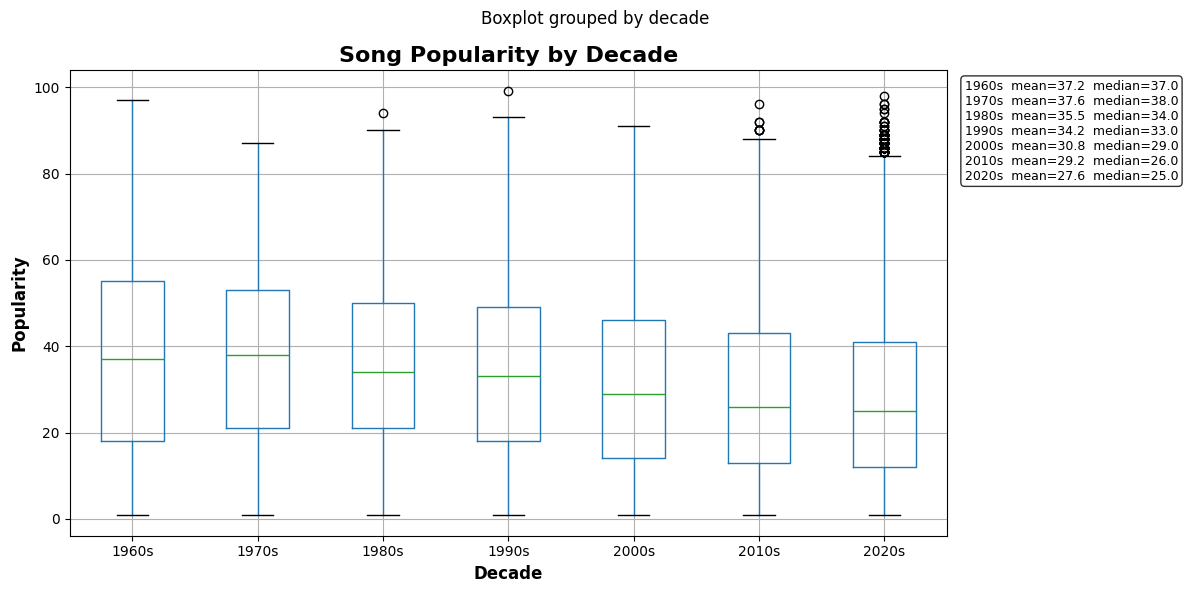

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

df.boxplot(column='popularity', by='decade', ax=ax)
ax.set_title('Song Popularity by Decade', fontsize=16, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12, fontweight='bold')
ax.set_ylabel('Popularity', fontsize=12, fontweight='bold')

# Build stats text per decade
stats_lines = []
for decade in sorted(df['decade'].unique()):
    group = df[df['decade'] == decade]['popularity']
    stats_lines.append(f"{decade}  mean={group.mean():.1f}  median={group.median():.1f}")

stats_text = "\n".join(stats_lines)
ax.text(1.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [30]:
stats, p = levene(sixties, seventies, eighties, ninties, y2k, tens, twenties)
print(f"Levene's test p = {p:.4f}")


Levene's test p = 0.0000


The trend observed in the descriptive stats analysis is corroborated the boxplots. There is a downward trend in average song popularity and in median song popularity over the decades, specifically in the 2000s. While the decade may be driving this trend it is important to note there is a stark difference in number of songs in the early decades and decades in the 2000s. the 2020's has 65k songs so the distribution is tighter around the center, while in the 60s there are only 780 songs that have more variation. The levene test corroborates the findings in the boxplot that the variance isn't equal. Although this is true, I am still going to use an ANOVA test. 

In [40]:
f_stat, p_value = f_oneway(sixties, seventies, eighties, ninties, y2k, tens, twenties)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.8f}")

if p_val < .05:
    print("Result: Reject the Null Hypothesis... at least one group's mean is significantly different ")
else:
    print("Result: Accept the Null Hypothesis... no significant difference between the groups' means")

F-statistic: 242.9023
p-value:     0.00000000
Result: Reject the Null Hypothesis... at least one group's mean is significantly different 


The incredibly high f-score (242) and low p-value (0.0) indicate that there is at least one group with a statistically different avg song popularity. I assumed that this would be the finding of the ANOVA test due to the differences observed in the boxplot distributions. The f-score of 242 means that the difference between the groups is 242x bigger than the varaince observed within the groups. 

In [42]:
tukey = pairwise_tukeyhsd(endog = df['popularity'], groups = df['decade'], alpha=.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
 1960s  1970s   0.4282 0.9989  -2.1171  2.9735  False
 1960s  1980s   -1.692 0.3457  -4.0545  0.6706  False
 1960s  1990s  -2.9385 0.0015  -5.1306 -0.7465   True
 1960s  2000s  -6.3243    0.0  -8.4358 -4.2129   True
 1960s  2010s  -7.9437    0.0 -10.0037 -5.8836   True
 1960s  2020s  -9.6047    0.0 -11.6458 -7.5635   True
 1970s  1980s  -2.1202 0.0236  -4.0761 -0.1642   True
 1970s  1990s  -3.3667    0.0  -5.1129 -1.6205   True
 1970s  2000s  -6.7525    0.0  -8.3964 -5.1087   True
 1970s  2010s  -8.3719    0.0  -9.9492 -6.7945   True
 1970s  2020s -10.0329    0.0 -11.5854 -8.4803   True
 1980s  1990s  -1.2465 0.1573  -2.7136  0.2205  False
 1980s  2000s  -4.6324    0.0   -5.976 -3.2887   True
 1980s  2010s  -6.2517    0.0  -7.5131 -4.9903   True
 1980s  2020s  -7.9127    0.0   -9.143 -6.6824   True
 1990s  2000s  -3.3858    0.

The 1960s and 1970s are statistically indistinguishable from each other (p = 0.999), and the 1960s and 1980s also fail to reach significance (p = 0.346). This tells us that the classic era of the 1960s through 1980s produced songs that perform at a broadly similar level in terms of Spotify popularity today, suggesting that whatever survivorship bias is lifting older songs applies relatively equally across those three decades.

The sharpest break in the data comes when comparing the 1960s and 1970s against the 1990s onward. Every comparison between the older decades and the 1990s, 2000s, 2010s, and 2020s returns a significant result (p < 0.05), and the mean differences grow steadily larger the further apart the decades are. The 1970s vs 2020s gap of 10.03 popularity points is the largest in the entire table, showing just how much the algorithm disadvantages newer releases relative to established classics.

Interestingly, the 1980s and 1990s are not significantly different from each other (p = 0.157), which suggests those two decades occupy a similar middle ground where neither is benefiting from the strongest survivorship effect of the 1960s and 1970s, nor as penalised as more recent output.

Every adjacent decade comparison from the 2000s onward is statistically significant, meaning each successive decade genuinely scores lower than the one before it. The 2000s vs 2010s gap (1.6 points), 2010s vs 2020s gap (1.7 points), and 2000s vs 2020s gap (3.3 points) are all significant, suggesting the downward trend is not just driven by outlier decades but is a consistent and ongoing pattern.

The overall picture is one of a steady structural decline in popularity scores as songs get more recent. This is almost certainly a feature of how Spotify calculates popularity rather than a genuine reflection of song quality; older catalogue songs in a dataset like this are disproportionately the ones that have accumulated decades of continuous streaming, while newer releases compete in a vastly larger pool where only a small number of tracks break through to high popularity scores.

In [45]:
grand_mean = df['popularity'].mean()
ss_btwn = sum(len(g)*(g.mean() - grand_mean)**2 for g in [sixties, seventies, eighties, ninties, y2k, tens, twenties])
ss_total = sum((df['popularity']- grand_mean)**2)
eta_sq = ss_btwn/ss_total


print(f"\nEta-squared: {eta_sq:.4f}")
if eta_sq < 0.01:
    print("Effect size: Negligible")
elif eta_sq < 0.06:
    print("Effect size: Small")
elif eta_sq < 0.14:
    print("Effect size: Medium")
else:
    print("Effect size: Large")


Eta-squared: 0.0132
Effect size: Small


This is the first test across all of my tests where the effect size wasn't negligible. Decade explains 1.32% of the variance in song popularity. This stat communicates that decade of release has a genuine, if modest, influence on how a song scores.The consistence decline in scores towards more decades likely reflect structural bias in the Spotify popularity algorithm rather than genuine differences in song quality.

# Overall Conclusions

Across both ANOVA tests in this notebook, the results follow a consistent and familiar pattern. Statistical significance was easy to achieve given the large sample sizes, but effect sizes told the more honest story about whether those differences actually matter.

For Test 1, the album format ANOVA returned an F-statistic of 19 and a significant p-value, leading us to reject the null hypothesis. However, the Tukey HSD table revealed that the entire result was driven by compilations underperforming singles and albums by roughly 1.8 popularity points. Singles and albums themselves were statistically indistinguishable from each other, with a mean difference of just 0.04 points and a p-value of 0.95. The eta-squared of 0.0003 confirmed that album format explains only 0.03% of the variance in song popularity, making it practically irrelevant as a predictor. An editorial or A&R team would gain nothing from using format as a signal in any popularity model.

Test 2 produced the most interesting result of the entire notebook series. The decade ANOVA returned an F-statistic of 242, and the Tukey HSD confirmed that most decade pairs were significantly different from each other. Older songs consistently scored higher, with the 1960s averaging 37.2 and the 2020s averaging 27.6. The eta-squared of 0.013 was the first effect size across all four notebooks to clear the negligible threshold, landing in the small but meaningful range. This suggests that decade of release has a genuine, if modest, influence on Spotify popularity scores. The most likely explanation is survivorship bias combined with algorithmic recency weighting — the older songs that remain in circulation today tend to be the ones that have stood the test of time, while the 2020s sample includes every new release regardless of longevity.

Taking a step back across all four notebooks, the clearest and most consistent finding is that artist-level factors, particularly artist popularity, are far stronger predictors of song popularity than any of the song-level or format-level variables tested here. Decade of release is the only variable beyond artist popularity that showed even a small effect size, and even then it likely reflects how the algorithm works rather than anything about the songs themselves.